In [1]:
import torch

In [53]:
X_mid_dict = torch.load('RAR_X_0.5.pth')
X_last_dict = torch.load('RAR_X_last.pth')


X_rbas = X_last_dict[list(X_last_dict.keys())[0]]

In [62]:
X_rbas[:,-1].max()

tensor(4.9999)

0


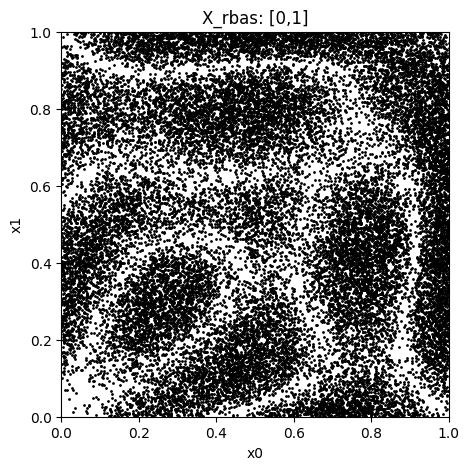

1


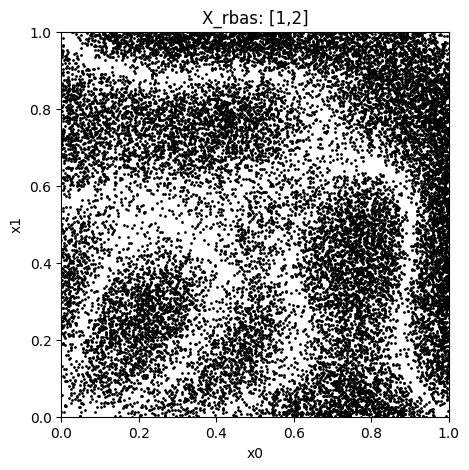

2


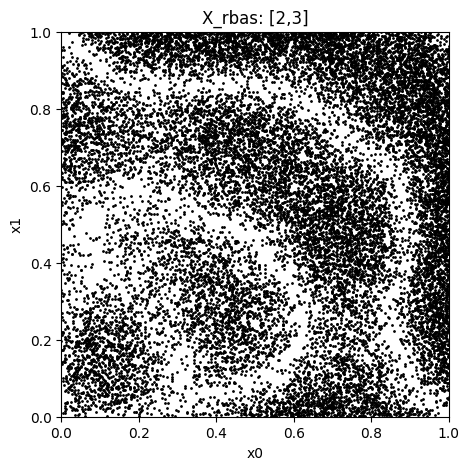

3


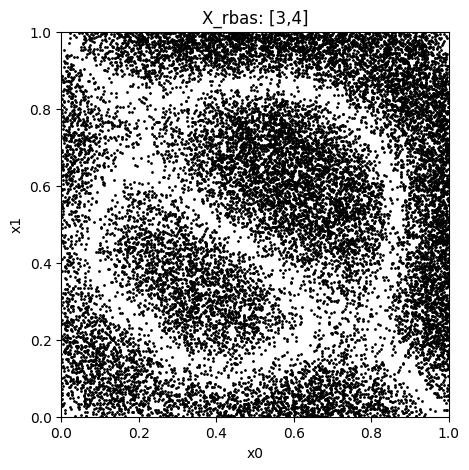

In [59]:
import matplotlib.pyplot as plt

for i in range(0,4,1):
    print(i)
    X_rbas_sp = X_rbas[(X_rbas[:,-1] > i) & (X_rbas[:,-1] < i+1)][:,:-1]
    X_rbas_sp.shape
    plt.figure(figsize=(5, 5))
    plt.scatter(X_rbas_sp[:, 0], X_rbas_sp[:, 1], c="black", s=1)
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.xlabel("x0")
    plt.ylabel("x1")
    plt.title(f"X_rbas: [{i},{i+1}]")
    plt.show()

In [65]:
import os, sys
src_dir = '/home/antos_j/diploma_sketchbook/PINN/src/'
sys.path.append(src_dir)
import architecture
model_path = '/home/antos_j/diploma_sketchbook/PINN/case0_HeatEq/run_adam/model.pth'

In [82]:
layers=[64,64,64,64]
head_fun = lambda out, X: out * torch.prod(torch.sin(torch.pi*X[:,:-1]), dim=1, keepdim=True)
model = architecture.PINN(3, layers, 1, head_fn=head_fun)
model.load_state_dict(torch.load(model_path, weights_only=True))
model.eval()

PINN(
  (act): Tanh()
  (net): Sequential(
    (0): Linear(in_features=3, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): Tanh()
    (6): Linear(in_features=64, out_features=64, bias=True)
    (7): Tanh()
    (8): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [71]:
model(X_rbas)

tensor([[0.7566],
        [0.0173],
        [0.4953],
        ...,
        [0.2356],
        [0.0244],
        [0.0148]], grad_fn=<MulBackward0>)

In [73]:
import pde_models as pde_mod
pde_model = pde_mod.HeatEquation(2)
pde_model.u_analytic

<bound method HeatEquation.u_analytic of <pde_models.HeatEquation object at 0x7fbea3c67b10>>

In [ ]:
for i in range(0,4,1):
    print(i)
    X_rbas_sp = X_rbas[(X_rbas[:,-1] > i) & (X_rbas[:,-1] < i+1)][:,:-1]
    X_rbas_sp.shape
    plt.figure(figsize=(5, 5))
    plt.imshow(X_rbas_sp[:, 0], X_rbas_sp[:, 1], c="black", s=1)
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.xlabel("x0")
    plt.ylabel("x1")
    plt.title(f"X_rbas: [{i},{i+1}]")
    plt.show()

In [88]:
pde_model.u_analytic(X_rbas).shape, model(X_rbas).shape

(torch.Size([102400, 1]), torch.Size([102400, 1]))

In [94]:
import viz
d = 2
def p_0(X):
    print(X.shape)
    #return pde_model.u_analytic(X[:,:-1])
    return model(X[:,:-1]).detach()
#p_0 = lambda X: pde_model.u_analytic(X[:,:-1])
#p_0 = lambda X: model(X[:,:-1]).detach()
plotter = viz.FunctionPlotter(d=d, x_start=0.0, x_end=1.0)
plotter.add_panel('p_0').heatmap(p_0)
plotter.show_plot()

torch.Size([10000, 3])


RuntimeError: mat1 and mat2 shapes cannot be multiplied (10000x2 and 3x64)